# Validate classifiers

This notebook will use the training dataset created by notebook `00b` and the features selected in `01a` to train and validate the PU models.

It will also calculate feature importance, via normalised (relative) Gini impurity, and permutation importance.

## Notebook setup

These cells set some of the important variables and definitions used throughout the notebook, based on the selected config file.

### Config

In [31]:
config_file = "config/.run_config.yml"

In [32]:
from lib.paths import PathConfigManager
pcm = PathConfigManager(config_file, notebook="01")

# =====================
# Filestructure
# =====================

# Base directories
plate_model_dir = pcm.PLATE_MODEL_DIR
points_data_dir = pcm.POINTS_DATA_DIR
output_dir = pcm.OUTPUT_DIR

pcm.create_directories()

# Input data filepaths
regions_filepath = pcm.REGIONS_PATH
training_data_filepath = pcm.TRAINING_DATA_PATH

# =====================
# Notebook scope
# =====================

# Gates for determining scope of notebook run (i.e. which feature sets can be selected from)
use_features = pcm.use_features

# If True, use training data extracted in notebook 00b, 00c
# Else, use pre-prepared training data downloaded from Zenodo
use_extracted_data = pcm.use_extracted_data

# If False, skip training the SVM models
create_svm = pcm.config["create_svm"]

# If False, skip training all regional models (PU and SVM)
create_regional_models = pcm.config["create_regional_models"]

# =====================
# Model training parameters
# =====================

# Timespan for plotting
min_time = pcm.config["timespan"]["min"]
max_time = pcm.config["timespan"]["max"]
times = range(min_time, max_time + 1)

# If this parameter is False, perform feature selection using all data for all models
# If True, perform feature selection for each model individually
use_same_features = pcm.config["use_same_features"]

# If this parameter is False, selected features must be specified below
# Otherwise, they will be selected automatically
automatic_feature_selection = pcm.config["automatic_feature_selection"]

# Random seed for reproducibility
random_seed = pcm.config["random_seed"]

# Number of processes to use
n_jobs = pcm.config["n_jobs"]

# Overwrite any existing output files
overwrite = pcm.config["overwrite_output"]

# Control verbosity level of logging output
verbose = pcm.config["verbose"]

### Imports

In [33]:
import warnings

import cartopy.crs as ccrs
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from cartopy.mpl.gridliner import (
    LATITUDE_FORMATTER,
    LONGITUDE_FORMATTER,
)
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from pulearn.bagging import BaggingPuClassifier
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import IterativeImputer
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import (
    Pipeline,
    make_pipeline,
)
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC

from lib.check_files import check_prepared_data
from lib.misc import (
    format_feature_name,
)
from lib.pu import (
    PU_PARAMS,
    COLUMNS_TO_DROP,
    PRESERVATION_COLUMNS,
    # downsample_unlabelled,
)

# Use figure style template in config directory
plt.style.use(pcm.CONFIG_DIR / "thesis.mplstyle")

# Suppress FutureWarning for some versions of pandas
pd.set_option('future.no_silent_downcasting', True)

# Suppress FutureWarning for some versions of Scikit-learn
%env PYTHONWARNINGS=ignore

# Suppress some other warnings
warnings.simplefilter("ignore", ConvergenceWarning)

env: PYTHONWARNINGS=ignore


/var/folders/vn/gbv894gx5fncbnm4wbnf90080000gn/T/ipykernel_84424/3382293809.py:47: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.


### Input and output files

In [34]:
if use_extracted_data:
    print(f"Using extracted training data in {points_data_dir}")
else:
    print(f"Using prepared training data in {pcm.PREPARED_DATA_DIR}")
    prep_dir = check_prepared_data(pcm.PREPARED_DATA_DIR, verbose=True)
    prep_dir = Path(prep_dir)
    grid_data_filepath = prep_dir / "grid_data.csv"
    training_filepath = prep_dir / "training_data_global.csv"

output_deposits = output_dir / "deposits"

pu_dir = output_dir / "PU"
pu_dir.mkdir(parents=True, exist_ok=True)
pu_basename = pu_dir / "classifier"

validation_dir = pu_dir / "cross_validation"
validation_dir.mkdir(parents=True, exist_ok=True)

importance_dir = pu_dir / "feature_importance"
importance_dir.mkdir(parents=True, exist_ok=True)
importance_basename = importance_dir / "feature_importance"

if create_svm:
    svm_dir = output_dir / "SVM"
    svm_dir.mkdir(parents=True, exist_ok=True)
    svm_basename = svm_dir / "classifier"

Using extracted training data in /Users/glados/Documents/Not Useless/Documents/University/2026/Honours/Data & Code/PUB-framework-Alfonso/data_extracted/zahirovic2022/polygons_points/trenches_9.0_deg_buffer


### Classifier parameters

In [35]:
# Parameters for models
imputer_params = {
    "random_state": random_seed,
    "add_indicator": False,
}
rf_params = {
    "random_state": random_seed,
    "n_estimators": 50,
    "n_jobs": 1,
}
pu_params = {
    **PU_PARAMS,
    "n_jobs": n_jobs,
    "random_state": random_seed,
    "n_estimators": 50,
    "balanced_subsample": True,
}
svm_params = {
    "kernel": "rbf",
    "probability": True,
    "random_state": random_seed,
}

Define model and preprocessing pipeline:

In [36]:
pu_model = BaggingPuClassifier(
    RandomForestClassifier(**rf_params),
    **pu_params
)
preprocessing = make_pipeline(
    IterativeImputer(**imputer_params),
    RobustScaler(),
    VarianceThreshold(),
)
pu_pipeline = Pipeline([("preprocessing", preprocessing), ("classifier", pu_model)])
pu_pipeline.set_output(transform="pandas")

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('iterativeimputer', ...), ('robustscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,estimator,None
,missing_values,nan
,sample_posterior,False


### Plotting setup & helpers

In [37]:
FW = 150 / 25.4  # Convert 150 mm to inches for figure width

In [38]:
def plot_auc_pr_curve(precision, recall, pr_auc, label, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(FW * 0.5, FW * 0.5))
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
    ax.plot(recall, precision, label=f"{label} (AUC = {pr_auc:.2f})")
    ax.legend()
    return ax

In [39]:
def plot_mean_pr_curve(pr_curves, output_path, title=None):
    """Plot mean ± IQR precision-recall curve across folds and save to disk."""
    recall_grid = np.linspace(0, 1, 100)
    precision_matrix = np.full((len(pr_curves), len(recall_grid)), np.nan)
    aucs = []
    for i, (precision, recall) in enumerate(pr_curves):
        sort_idx = np.argsort(recall)
        recall_s, precision_s = recall[sort_idx], precision[sort_idx]
        aucs.append(auc(recall_s, precision_s))
        mask = (recall_grid >= recall_s[0]) & (recall_grid <= recall_s[-1])
        precision_matrix[i, mask] = np.interp(recall_grid[mask], recall_s, precision_s)

    mean_p = np.nanmean(precision_matrix, axis=0)
    p25 = np.nanpercentile(precision_matrix, 25, axis=0)
    p75 = np.nanpercentile(precision_matrix, 75, axis=0)
    mean_auc, std_auc = np.mean(aucs), np.std(aucs)

    fig, ax = plt.subplots(figsize=(FW * 0.5, FW * 0.5))
    ax.plot(recall_grid, mean_p, label=f"Mean (AUC = {mean_auc:.2f} ± {std_auc:.2f})")
    ax.fill_between(recall_grid, p25, p75, alpha=0.3, label="IQR (25th–75th %ile)")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    if title:
        ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    for ext in (".pdf", ".png"):
        fig.savefig(f"{output_path}{ext}", dpi=350, bbox_inches="tight")
    return fig, ax

In [40]:
_threshold_grid = np.linspace(0, 1, 100)

def plot_recall_curve(recall_pos, label, ax=None):
    """Plot recall of positives vs threshold for one fold."""
    if ax is None:
        _, ax = plt.subplots(figsize=(FW * 0.5, FW * 0.5))
        ax.set_xlabel("Threshold")
        ax.set_ylabel("Recall (positives)")
    ax.plot(_threshold_grid, recall_pos, label=label)
    ax.legend()
    return ax

def plot_mean_recall_curve(recall_curve_sets, output_path, title=None):
    """Plot mean ± IQR recall-vs-threshold for one or more fold sets and save."""
    fig, ax = plt.subplots(figsize=(FW * 0.5, FW * 0.5))
    # ax.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), "0.4--", label="Random chance (AUC = 0.50)")
    for label, curves in recall_curve_sets.items():
        recall_matrix = np.vstack(curves)
        mean_r = recall_matrix.mean(axis=0)
        p25 = np.percentile(recall_matrix, 25, axis=0)
        p75 = np.percentile(recall_matrix, 75, axis=0)
        (line,) = ax.plot(_threshold_grid, mean_r, label=label)
        ax.fill_between(_threshold_grid, p25, p75, alpha=0.2, color=line.get_color())
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Recall (positives)")
    if title:
        ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    for ext in (".pdf", ".png"):
        fig.savefig(f"{output_path}{ext}", dpi=350, bbox_inches="tight")
    return fig, ax

## Training data

These cells load and plot the training data.

In [41]:
data = pd.read_csv(training_data_filepath)

data.columns

Index(['present_lon', 'present_lat', 'age (Ma)', 'Cu (Mt)', 'source', 'label',
       'plate_id', 'lon', 'lat', 'overriding_plate_id',
       ...
       'mantle_relative_east_velocity_lab+160km (cm/yr)',
       'mantle_relative_north_velocity_lab+160km (cm/yr)',
       'mantle_relative_speed_lab+160km (cm/yr)',
       'relative_velocity_parallel_to_plate_lab+160km (cm/yr)',
       'relative_velocity_transverse_to_plate_lab+160km (cm/yr)',
       'lab_depth_delta (km/timestep)',
       '1000k_isotherm_depth_delta (km/timestep)',
       'sublithospheric_cold_anomaly_thickness_delta (km/timestep)',
       'cold_anomaly_magnitude_delta (K/timestep)', 'region'],
      dtype='str', length=138)

### Columns to drop

In [42]:
# Drop individual water/carbon components, only use totals
component_columns = {
    "base_lithosphere_water_thickness (m)",
    "sedimentary_bound_water_thickness (m)",
    "sedimentary_pore_water_thickness (m)",
    "mantle_lithosphere_water_thickness (m)",
    "crustal_pore_water_thickness (m)",
    "crustal_bound_water_thickness (m)",
    "subducted_carbonate_volume (m)",
    "carbonate_carbon_density (t/m^2)",
    "carbonate_thickness (m)",
    "crustal_carbon_density (t/m^2)",
}
# Use orthogonal/parallel velocity vector components
component_columns |= {
    "subducting_plate_absolute_velocity (cm/yr)",
    "convergence_rate (cm/yr)",
    "trench_velocity (cm/yr)",
}
# Drop oceanic crust thickness and convergence rate,
# only use slab flux (product of the two components)
component_columns |= {
    "convergence_rate_orthogonal (cm/yr)",
    # "seafloor_age (Ma)",
    "plate_thickness (m)",
}
# Drop orthogonal components of velocity to prevent spatial leakage;
# use only overall magnitude
component_columns |= {
    component for component in data.columns if "east" in component or "north" in component
}

### Load training data

In [43]:
data = pd.read_csv(training_data_filepath)

# Remove duplicate points
# Duplicates arise from a one-to-many overriding-plate
# spatial join in combine_point_data() (notebook 00b).
# Deduplication prevents model bias from over-representation of certain locations.
data = data.drop_duplicates(subset=["lon", "lat", "age (Ma)"], keep="first")

# Skip regions with < 50 deposits
regions_to_skip = set()
for region, subset in data.groupby("region"):
    if (subset["label"] == "positive").sum() < 50:
        regions_to_skip.add(region)
data = data[~data["region"].isin(regions_to_skip)]

cleaned = data.drop(
    columns=list(COLUMNS_TO_DROP | PRESERVATION_COLUMNS | component_columns),
    errors="ignore",
)

print("Training data summary:")
print(data.groupby(["region", "label"]).size())
print("\nOverall class distribution:")
print(data.groupby(["label"]).size())

Training data summary:
region          label     
East Asia       negative         8
                positive       213
                unlabelled    6939
North America   negative        58
                positive       441
                unlabelled    7016
South America   negative       642
                positive       175
                unlabelled    7291
Southeast Asia  negative        13
                positive       143
                unlabelled    4480
Tethys          negative        12
                positive       466
                unlabelled    5199
dtype: int64

Overall class distribution:
label
negative        733
positive       1438
unlabelled    30925
dtype: int64


In [60]:
data["arc_trench_distance (km)"].describe()

count    33096.000000
mean       143.883716
std        115.306722
min         68.091868
25%         99.904462
50%        104.185862
75%        146.027128
max       1371.097201
Name: arc_trench_distance (km), dtype: float64

In [62]:
data["distance_to_trench (km)"].describe()

count    33096.000000
mean       401.439809
std        269.055095
min          0.106446
25%        185.752526
50%        369.784786
75%        587.727533
max       4968.318354
Name: distance_to_trench (km), dtype: float64

### Wrangle training data

In [44]:
# Maintain a reference containing metadata fields
data_pu = data[data["label"].isin({"positive", "unlabelled"})]
# Wrangle the training data to the required format
train_pu = cleaned[cleaned["label"].isin({"positive", "unlabelled"})]
x_pu = train_pu.drop(columns="label")
y_pu = train_pu["label"].replace({"positive": 1, "unlabelled": 0}).astype("int")

# Load the features selected in notebook 01a
selected_features = pd.read_csv(output_dir / "selected_features.csv")["selected_features"].tolist()
X_pu = x_pu[selected_features]

## Global PU model validation

In [45]:
recall_dict = {}

### AUC-PR for full model

Evaluate on training set to test recall. Not a measure of generalisation performance, but at least checks that the model can learn something from the data.

PR AUC = 0.998, Average Precision = 0.998


<Axes: xlabel='Recall', ylabel='Precision'>

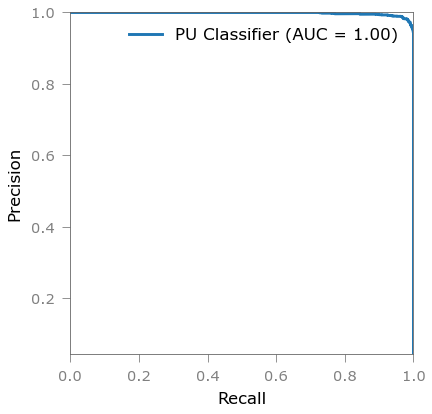

In [46]:
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

pu_pipeline.fit(X_pu, y_pu)
y_scores = pu_pipeline.predict_proba(X_pu)[:, 1]
precision, recall, _ = precision_recall_curve(y_pu, y_scores)
pr_auc = auc(recall, precision)
avg_precision = average_precision_score(y_pu, y_scores)
# Plot precision-recall curves
print(f"PR AUC = {pr_auc:.3f}, Average Precision = {avg_precision:.3f}")
plot_auc_pr_curve(precision, recall, pr_auc, label="PU Classifier")

### Standard K-Folds cross-validation

Baseline cross-validation with no spatial or geological grouping structure.

Fold 1: PR AUC = 0.858, Average Precision = 0.858
Fold 2: PR AUC = 0.878, Average Precision = 0.878
Fold 3: PR AUC = 0.787, Average Precision = 0.787
Fold 4: PR AUC = 0.883, Average Precision = 0.883
Fold 5: PR AUC = 0.846, Average Precision = 0.846
Fold 6: PR AUC = 0.831, Average Precision = 0.831
Fold 7: PR AUC = 0.873, Average Precision = 0.873
Fold 8: PR AUC = 0.856, Average Precision = 0.856
Fold 9: PR AUC = 0.843, Average Precision = 0.844
Fold 10: PR AUC = 0.847, Average Precision = 0.847


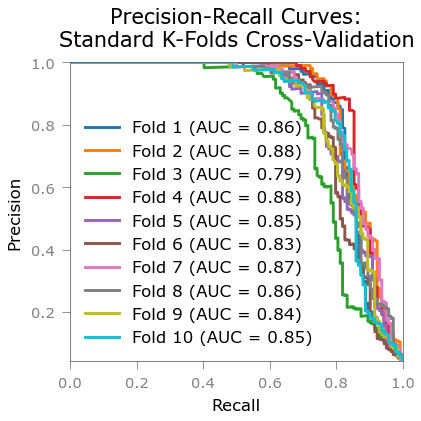

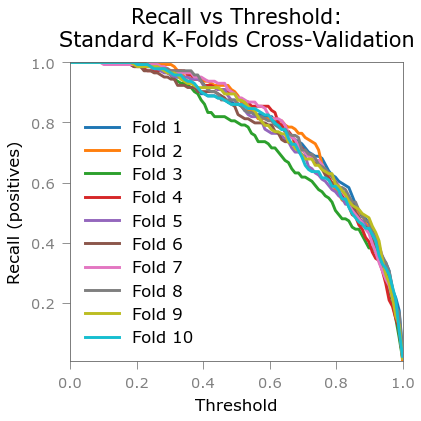

In [47]:
n_folds = 5
n_repeats = 1

rskf = RepeatedStratifiedKFold(n_splits=n_folds, n_repeats=n_repeats, random_state=random_seed)

fig_pr, ax_pr = plt.subplots(figsize=(FW * 0.5, FW * 0.5))
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall Curves:\nStandard K-Folds Cross-Validation")

fig_r, ax_r = plt.subplots(figsize=(FW * 0.5, FW * 0.5))
ax_r.set_xlabel("Threshold")
ax_r.set_ylabel("Recall (positives)")
ax_r.set_title("Recall vs Threshold:\nStandard K-Folds Cross-Validation")

pr_curves = []
test_recall_curves = []
train_recall_curves = []
for fold, (train_index, test_index) in enumerate(rskf.split(X_pu, y_pu)):
    X_train, X_test = X_pu.iloc[train_index], X_pu.iloc[test_index]
    y_train, y_test = y_pu.iloc[train_index], y_pu.iloc[test_index]
    pu_pipeline.fit(X_train, y_train)
    y_scores = pu_pipeline.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = auc(recall, precision)
    avg_precision = average_precision_score(y_test, y_scores)
    fold_label = f"R{fold // n_folds + 1}/Fold {fold % n_folds + 1}" if n_repeats > 1 else f"Fold {fold + 1}"
    print(f"{fold_label}: PR AUC = {pr_auc:.3f}, Average Precision = {avg_precision:.3f}")
    plot_auc_pr_curve(precision, recall, pr_auc, label=fold_label, ax=ax_pr)
    pr_curves.append((precision, recall))
    recall_pos = (y_scores[y_test.values == 1][:, None] >= _threshold_grid).mean(axis=0)
    plot_recall_curve(recall_pos, label=fold_label, ax=ax_r)
    test_recall_curves.append(recall_pos)
    train_recall_curves.append((pu_pipeline.predict_proba(X_train)[:, 1][y_train.values == 1][:, None] >= _threshold_grid).mean(axis=0))

fig_pr.tight_layout()
fig_r.tight_layout()

(<Figure size 442.913x442.913 with 1 Axes>,
 <Axes: title={'center': 'Mean Recall vs Threshold:\nStandard K-Folds Cross-Validation'}, xlabel='Threshold', ylabel='Recall (positives)'>)

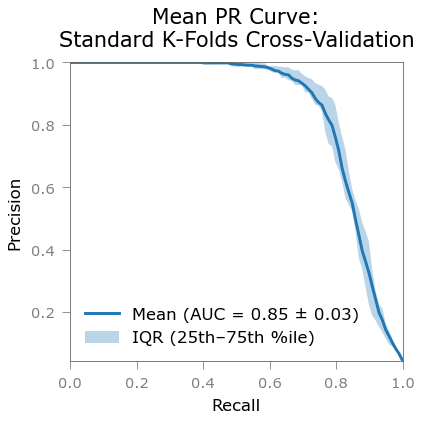

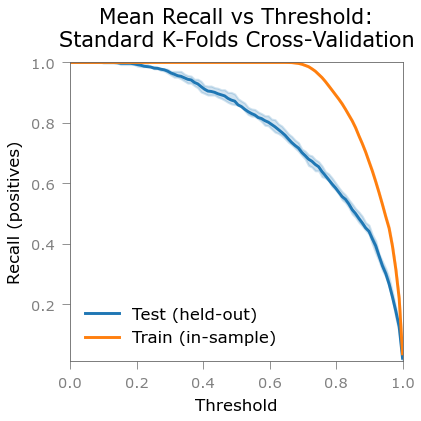

In [48]:
_standard_recall_sets = {
    "Test (held-out)": test_recall_curves,
    "Train (in-sample)": train_recall_curves,
}
recall_dict["standard"] = _standard_recall_sets

plot_mean_pr_curve(
    pr_curves,
    validation_dir / "standard_cv_mean_pr",
    title="Mean PR Curve:\nStandard K-Folds Cross-Validation",
)
plot_mean_recall_curve(
    _standard_recall_sets,
    validation_dir / "standard_cv_mean_recall",
    title="Mean Recall vs Threshold:\nStandard K-Folds Cross-Validation",
)

### Regional cross-validation

Hold one region's points out and train the classifier on the rest of the regions. Use the held-out region for testing.

In [49]:
regions = data[data["label"].isin({"positive", "unlabelled"})]["region"]
region_groups, group_labels = pd.factorize(regions)

for group, label in zip(np.unique(region_groups), group_labels):
    print(f"Group {group}: {label}")

Group 0: Tethys
Group 1: Southeast Asia
Group 2: East Asia
Group 3: North America
Group 4: South America


Fold Tethys: PR AUC = 0.130, Average Precision = 0.131
Fold Southeast Asia: PR AUC = 0.034, Average Precision = 0.035
Fold East Asia: PR AUC = 0.044, Average Precision = 0.045
Fold North America: PR AUC = 0.063, Average Precision = 0.064
Fold South America: PR AUC = 0.021, Average Precision = 0.021


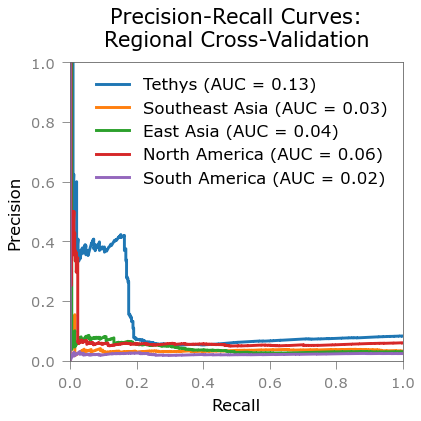

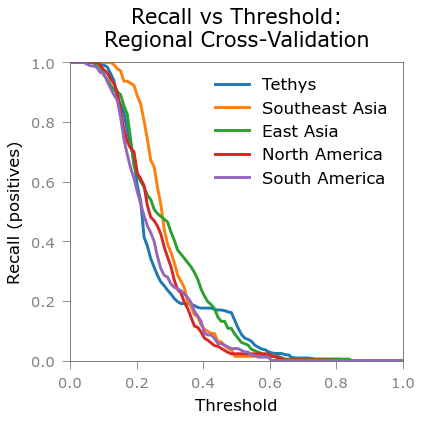

In [50]:
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()
fig_pr, ax_pr = plt.subplots(figsize=(FW * 0.5, FW * 0.5))
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall Curves:\nRegional Cross-Validation")

fig_r, ax_r = plt.subplots(figsize=(FW * 0.5, FW * 0.5))
ax_r.set_xlabel("Threshold")
ax_r.set_ylabel("Recall (positives)")
ax_r.set_title("Recall vs Threshold:\nRegional Cross-Validation")

pr_curves = []
test_recall_curves = []
train_recall_curves = []
for train_index, test_index in logo.split(X_pu, groups=region_groups):
    X_train, X_test = X_pu.iloc[train_index], X_pu.iloc[test_index]
    y_train, y_test = y_pu.iloc[train_index], y_pu.iloc[test_index]
    pu_pipeline.fit(X_train, y_train)
    y_scores = pu_pipeline.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = auc(recall, precision)
    avg_precision = average_precision_score(y_test, y_scores)
    fold_label = regions.iloc[test_index].iloc[0]
    print(f"Fold {fold_label}: PR AUC = {pr_auc:.3f}, Average Precision = {avg_precision:.3f}")
    plot_auc_pr_curve(precision, recall, pr_auc, label=fold_label, ax=ax_pr)
    pr_curves.append((precision, recall))
    recall_pos = (y_scores[y_test.values == 1][:, None] >= _threshold_grid).mean(axis=0)
    plot_recall_curve(recall_pos, label=fold_label, ax=ax_r)
    test_recall_curves.append(recall_pos)
    train_recall_curves.append((pu_pipeline.predict_proba(X_train)[:, 1][y_train.values == 1][:, None] >= _threshold_grid).mean(axis=0))

fig_pr.tight_layout()
fig_r.tight_layout()

(<Figure size 442.913x442.913 with 1 Axes>,
 <Axes: title={'center': 'Mean Recall vs Threshold:\nRegional Cross-Validation'}, xlabel='Threshold', ylabel='Recall (positives)'>)

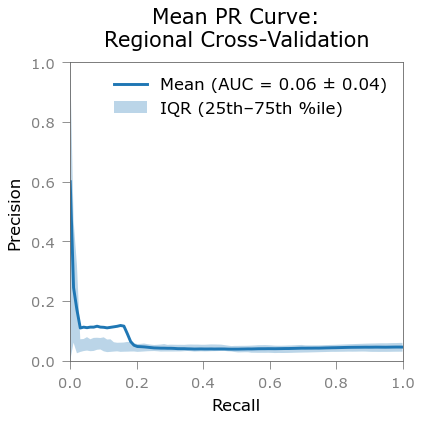

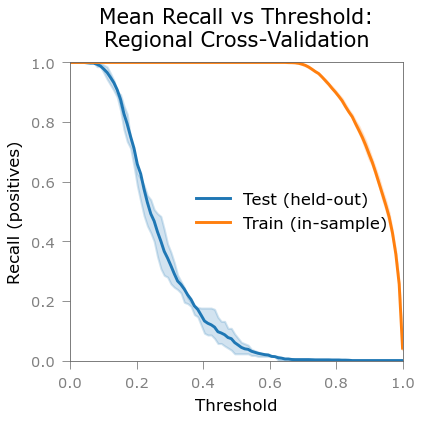

In [51]:
_regional_recall_sets = {
    "Test (held-out)": test_recall_curves,
    "Train (in-sample)": train_recall_curves,
}
recall_dict["regional"] = _regional_recall_sets

plot_mean_pr_curve(
    pr_curves,
    validation_dir / "regional_cv_mean_pr",
    title="Mean PR Curve:\nRegional Cross-Validation",
)
plot_mean_recall_curve(
    _regional_recall_sets,
    validation_dir / "regional_cv_mean_recall",
    title="Mean Recall vs Threshold:\nRegional Cross-Validation",
)

### Spatially-stratified cross-validation

In [52]:
lon_spacing = 10
lat_spacing = 10
time_spacing = 10

lon_grid = np.floor(data_pu["lon"] / lon_spacing) * lon_spacing
lat_grid = np.floor(data_pu["lat"] / lat_spacing) * lat_spacing
time_grid = np.floor(data_pu["age (Ma)"] / time_spacing) * time_spacing

spatial_groups, _ = pd.factorize(
    lon_grid + lat_grid*100 + time_grid*10000
)

Fold 1: PR AUC = 0.623, Average Precision = 0.623
Fold 2: PR AUC = 0.624, Average Precision = 0.624
Fold 3: PR AUC = 0.703, Average Precision = 0.703
Fold 4: PR AUC = 0.475, Average Precision = 0.476
Fold 5: PR AUC = 0.574, Average Precision = 0.574


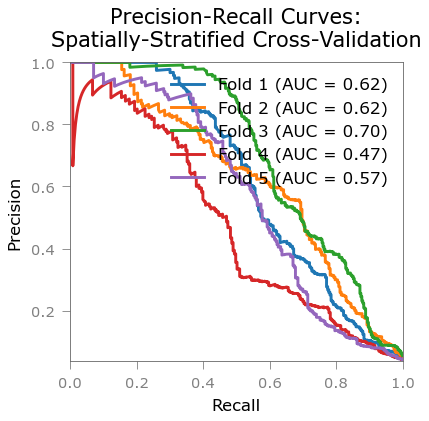

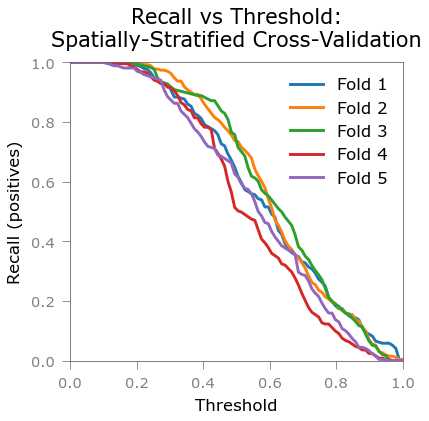

In [53]:
from sklearn.model_selection import StratifiedGroupKFold

n_folds = 5
n_repeats = 1

fig, ax = plt.subplots(figsize=(FW * 0.5, FW * 0.5))
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves:\nSpatially-Stratified Cross-Validation")

fig_r, ax_r = plt.subplots(figsize=(FW * 0.5, FW * 0.5))
ax_r.set_xlabel("Threshold")
ax_r.set_ylabel("Recall (positives)")
ax_r.set_title("Recall vs Threshold:\nSpatially-Stratified Cross-Validation")

pr_curves = []
test_recall_curves = []
train_recall_curves = []
for repeat in range(n_repeats):
    sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=random_seed + repeat)
    for fold, (train_index, test_index) in enumerate(sgkf.split(X_pu, y_pu, groups=spatial_groups)):
        X_train, y_train = X_pu.iloc[train_index], y_pu.iloc[train_index]
        X_test, y_test = X_pu.iloc[test_index], y_pu.iloc[test_index]
        pu_pipeline.fit(X_train, y_train)
        y_scores = pu_pipeline.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_scores)
        pr_auc = auc(recall, precision)
        avg_precision = average_precision_score(y_test, y_scores)
        fold_label = f"R{repeat + 1}/Fold {fold + 1}" if n_repeats > 1 else f"Fold {fold + 1}"
        print(f"{fold_label}: PR AUC = {pr_auc:.3f}, Average Precision = {avg_precision:.3f}")
        plot_auc_pr_curve(precision, recall, pr_auc, label=fold_label, ax=ax)
        pr_curves.append((precision, recall))
        recall_pos = (y_scores[y_test.values == 1][:, None] >= _threshold_grid).mean(axis=0)
        plot_recall_curve(recall_pos, label=fold_label, ax=ax_r)
        test_recall_curves.append(recall_pos)
        train_recall_curves.append((pu_pipeline.predict_proba(X_train)[:, 1][y_train.values == 1][:, None] >= _threshold_grid).mean(axis=0))

fig.tight_layout()
fig_r.tight_layout()

(<Figure size 442.913x442.913 with 1 Axes>,
 <Axes: title={'center': 'Mean Recall vs Threshold:\nSpatially-Stratified Cross-Validation'}, xlabel='Threshold', ylabel='Recall (positives)'>)

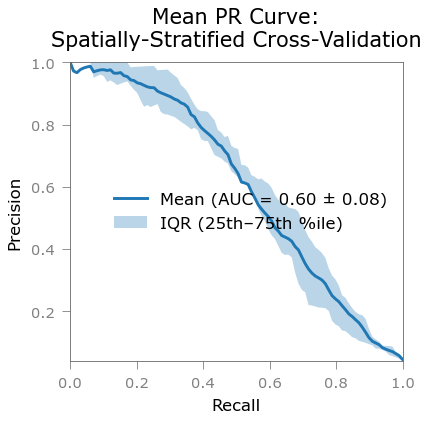

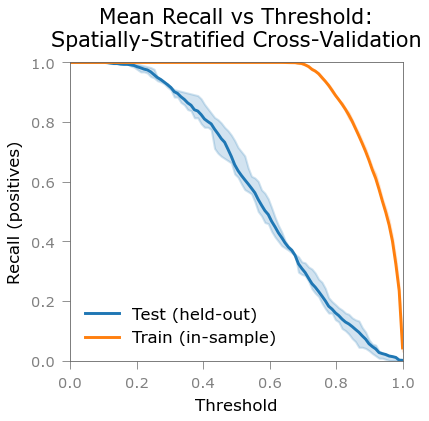

In [54]:
_spatial_recall_sets = {
    "Test (held-out)": test_recall_curves,
    "Train (in-sample)": train_recall_curves,
}
recall_dict["spatial"] = _spatial_recall_sets

plot_mean_pr_curve(
    pr_curves,
    validation_dir / "spatial_cv_mean_pr",
    title="Mean PR Curve:\nSpatially-Stratified Cross-Validation",
)
plot_mean_recall_curve(
    _spatial_recall_sets,
    validation_dir / "spatial_cv_mean_recall",
    title="Mean Recall vs Threshold:\nSpatially-Stratified Cross-Validation",
)

## Train regional models

In [55]:
# Bleh

## Feature importance

Here we plot impurity (Gini) feature importance values for each of the PU models.

In [56]:
# Cross-validation iterator
n_splits = 5
n_repeats = 1
cv = RepeatedStratifiedKFold(
    n_splits=n_splits,
    n_repeats=n_repeats,
    random_state=random_seed,
)

# Plot parameters
label_size = 16
tick_size = 12
title_size = 18

### Global model

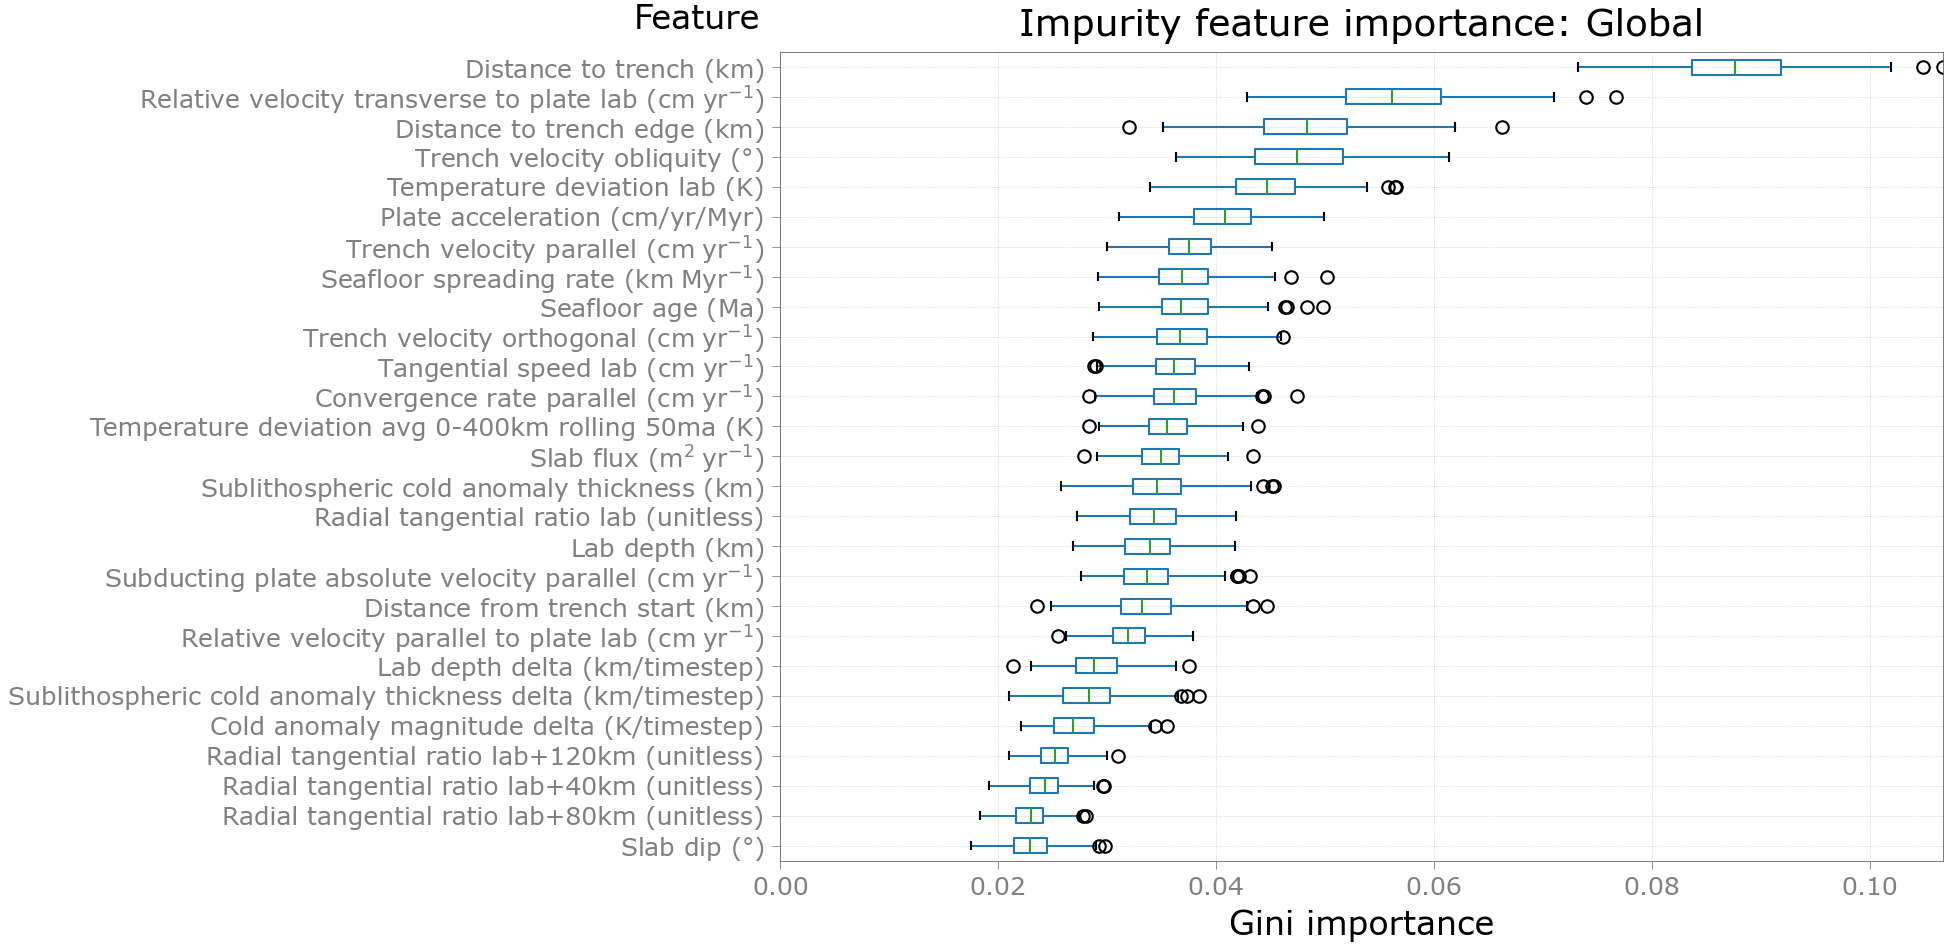

In [57]:
# Extract importances (use cross-validation for extra robustness)
model = joblib.load(pu_basename.with_suffix(".joblib"))
feature_names = model.feature_names_in_
replace = {"positive": 1, "negative": 0, "unlabelled": 0}
importances = []
for train_idx, _ in cv.split(cleaned, cleaned["label"]):
    data_train = cleaned.iloc[train_idx, :]
    data_train = data_train[data_train["label"] != "negative"]
    X_train = data_train[feature_names]
    y_train = data_train["label"].replace(replace).infer_objects()

    clf = clone(model)
    clf.fit(X_train, y_train)
    df_results = pd.DataFrame(
        np.vstack(
            [
                i.feature_importances_
                for i in clf["classifier"].estimators_
            ]
        ),
        columns=clf["preprocessing"].get_feature_names_out(),
    )
    importances.append(df_results)
importances = pd.concat(importances, ignore_index=True)
importances = importances[
    importances.median().sort_values(ascending=False).index
]
importances.to_csv(importance_basename.with_suffix(".csv"), index=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
importances.iloc[:, ::-1].boxplot(vert=False, ax=ax)
ax.grid(linestyle="dotted")
ax.set_xlim(0)
ax.set_xlabel(
    "Gini importance",
    fontsize=label_size,
)
ax.set_ylabel(
    "Feature",
    rotation=0,
    ha="right",
    fontsize=label_size,
)
ax.yaxis.set_label_coords(x=-0.017, y=1.02)
ax.set_title(
    "Impurity feature importance: Global",
    fontsize=title_size,
)
ax.set_yticks(
    ax.get_yticks(),
    [
        format_feature_name(i.get_text())
        for i in ax.get_yticklabels()
    ]
)
ax.tick_params(labelsize=tick_size)
for ext in (".pdf", ".png"):
    fig.savefig(
        importance_basename.with_suffix(ext),
        dpi=350,
        bbox_inches="tight",
    )

### Regional models

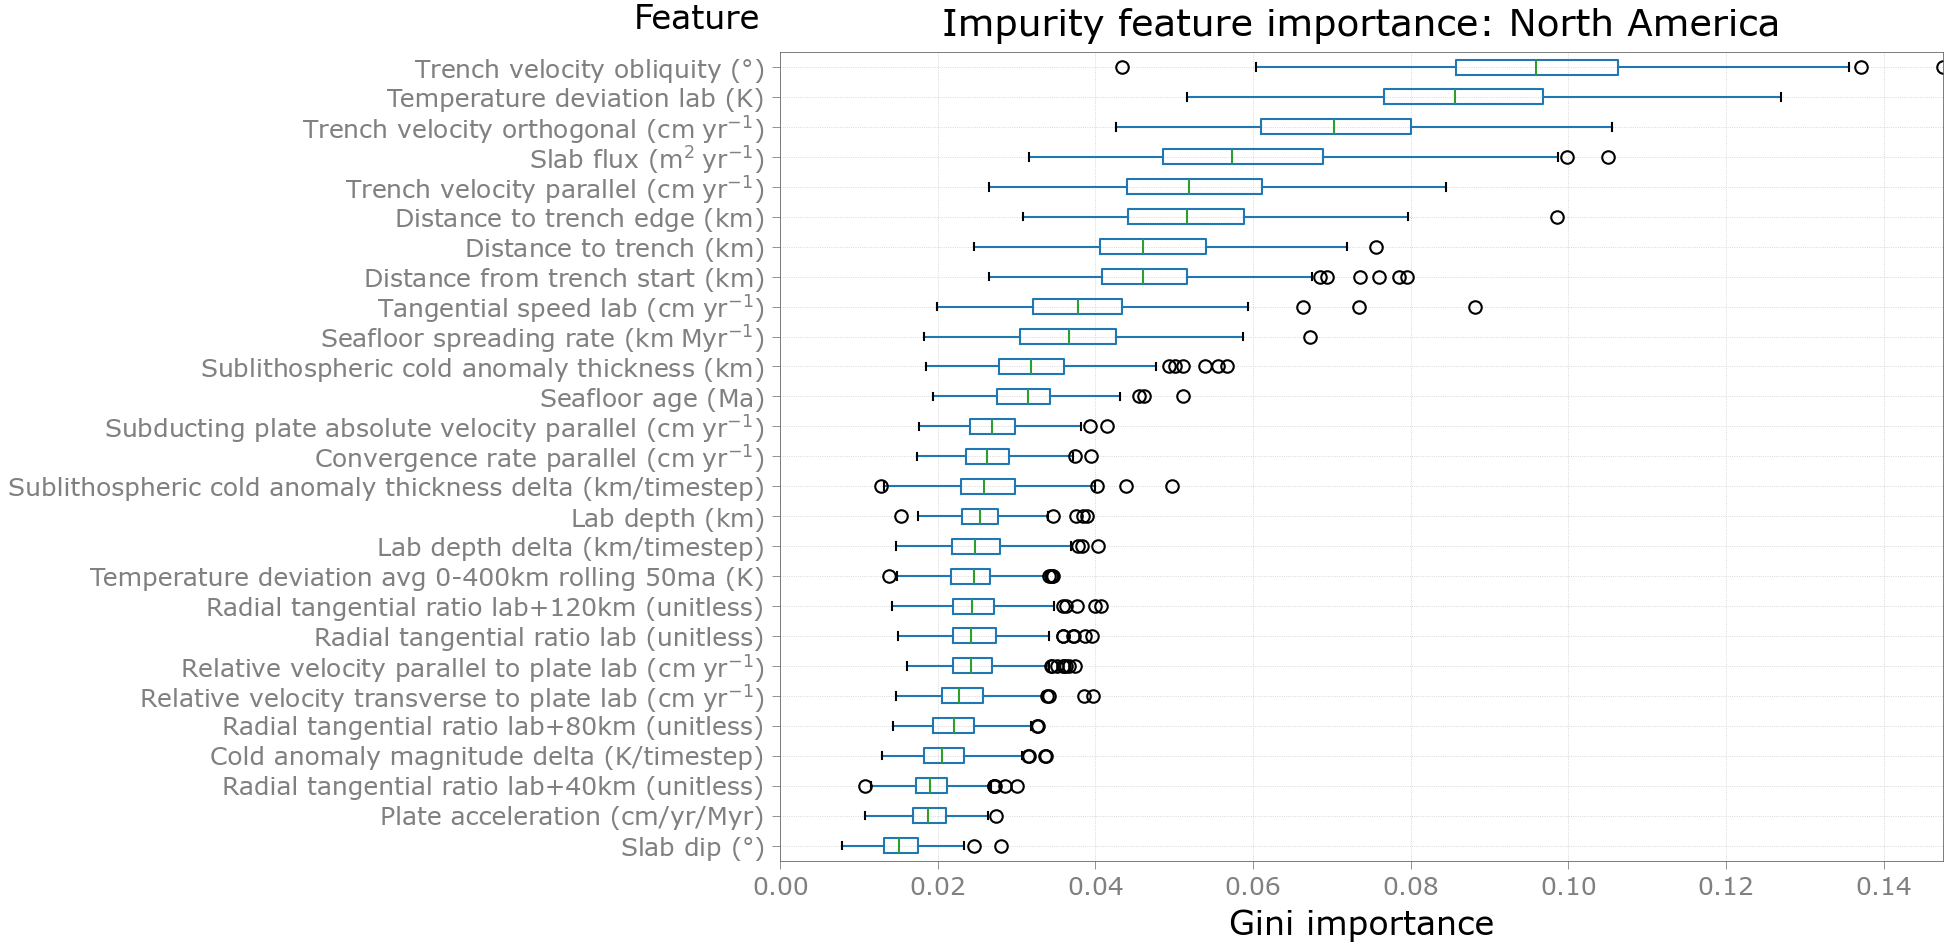

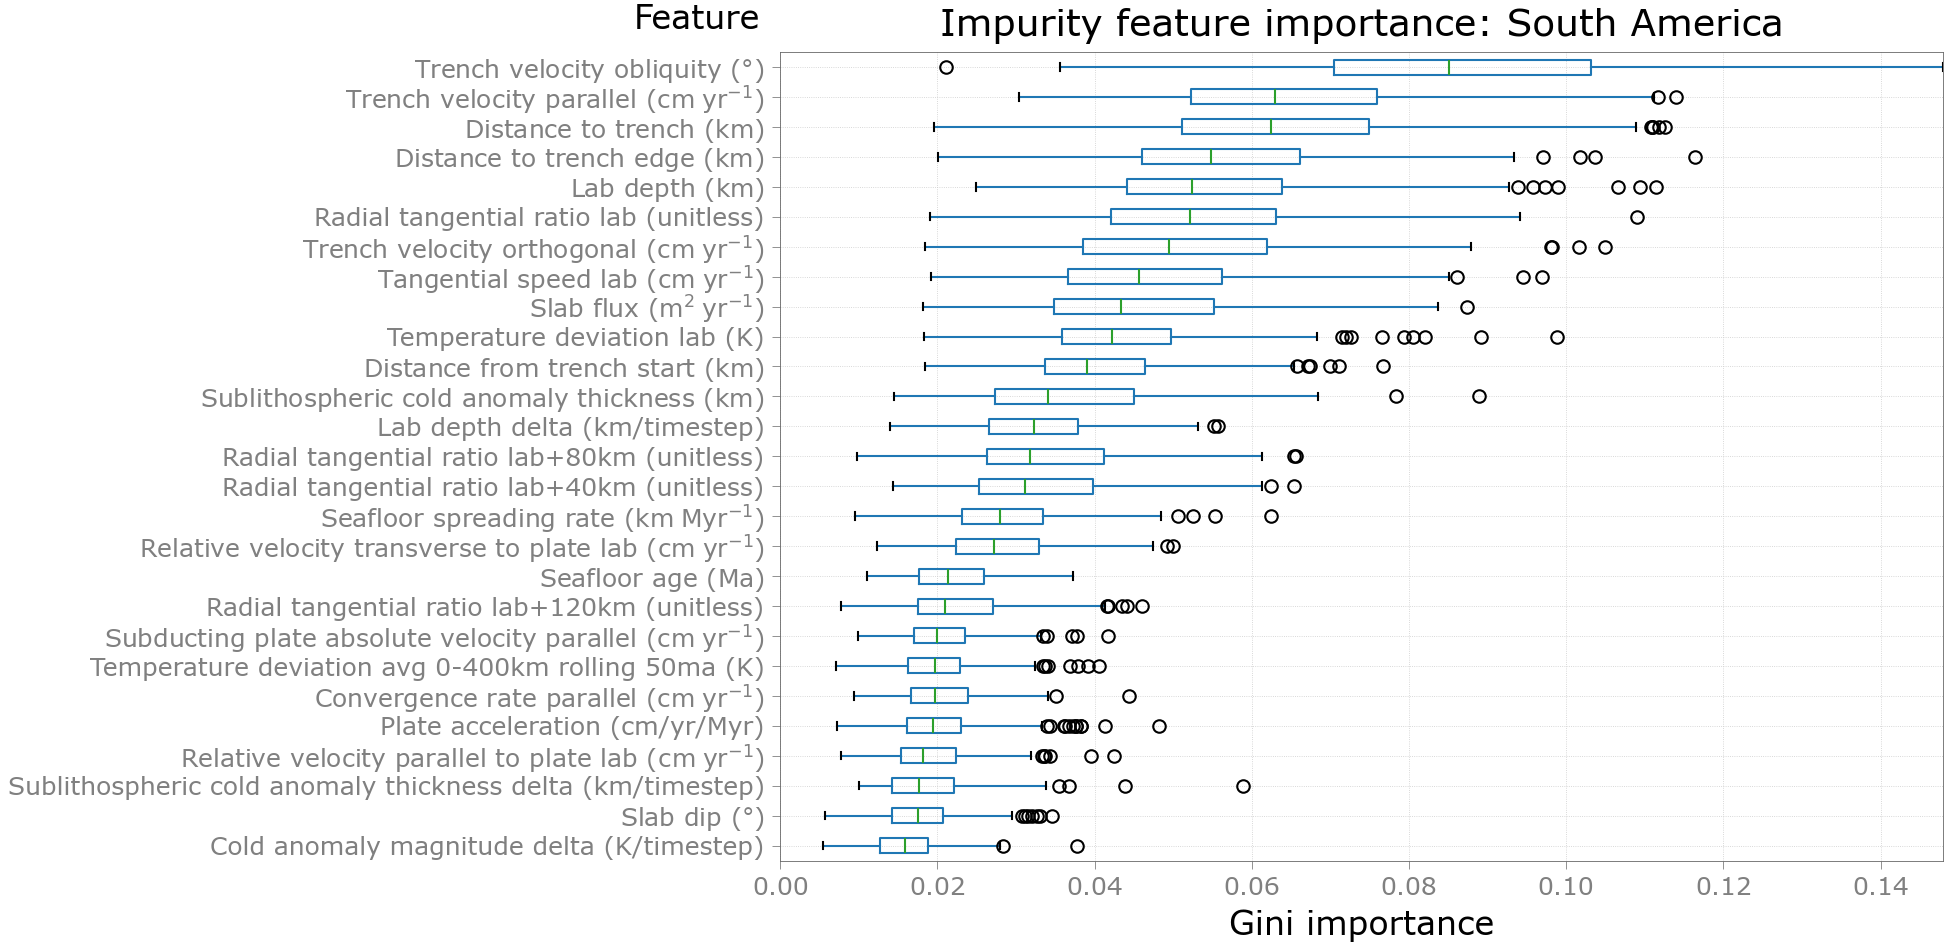

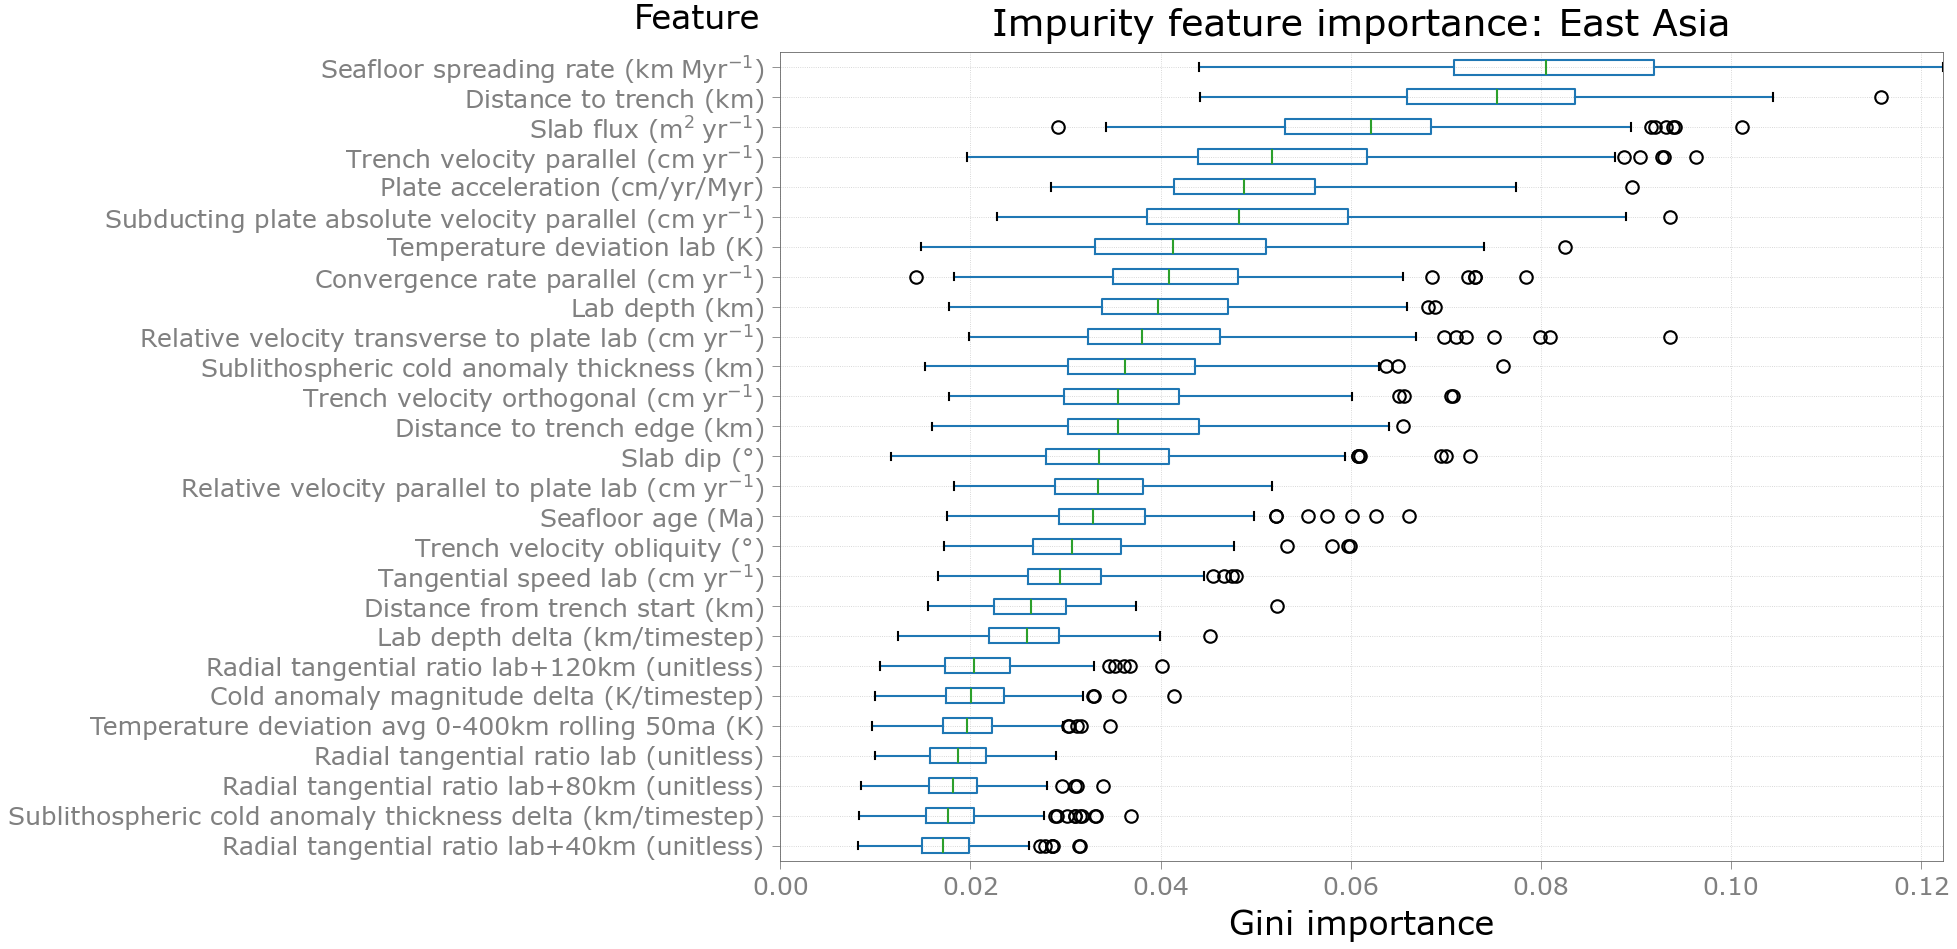

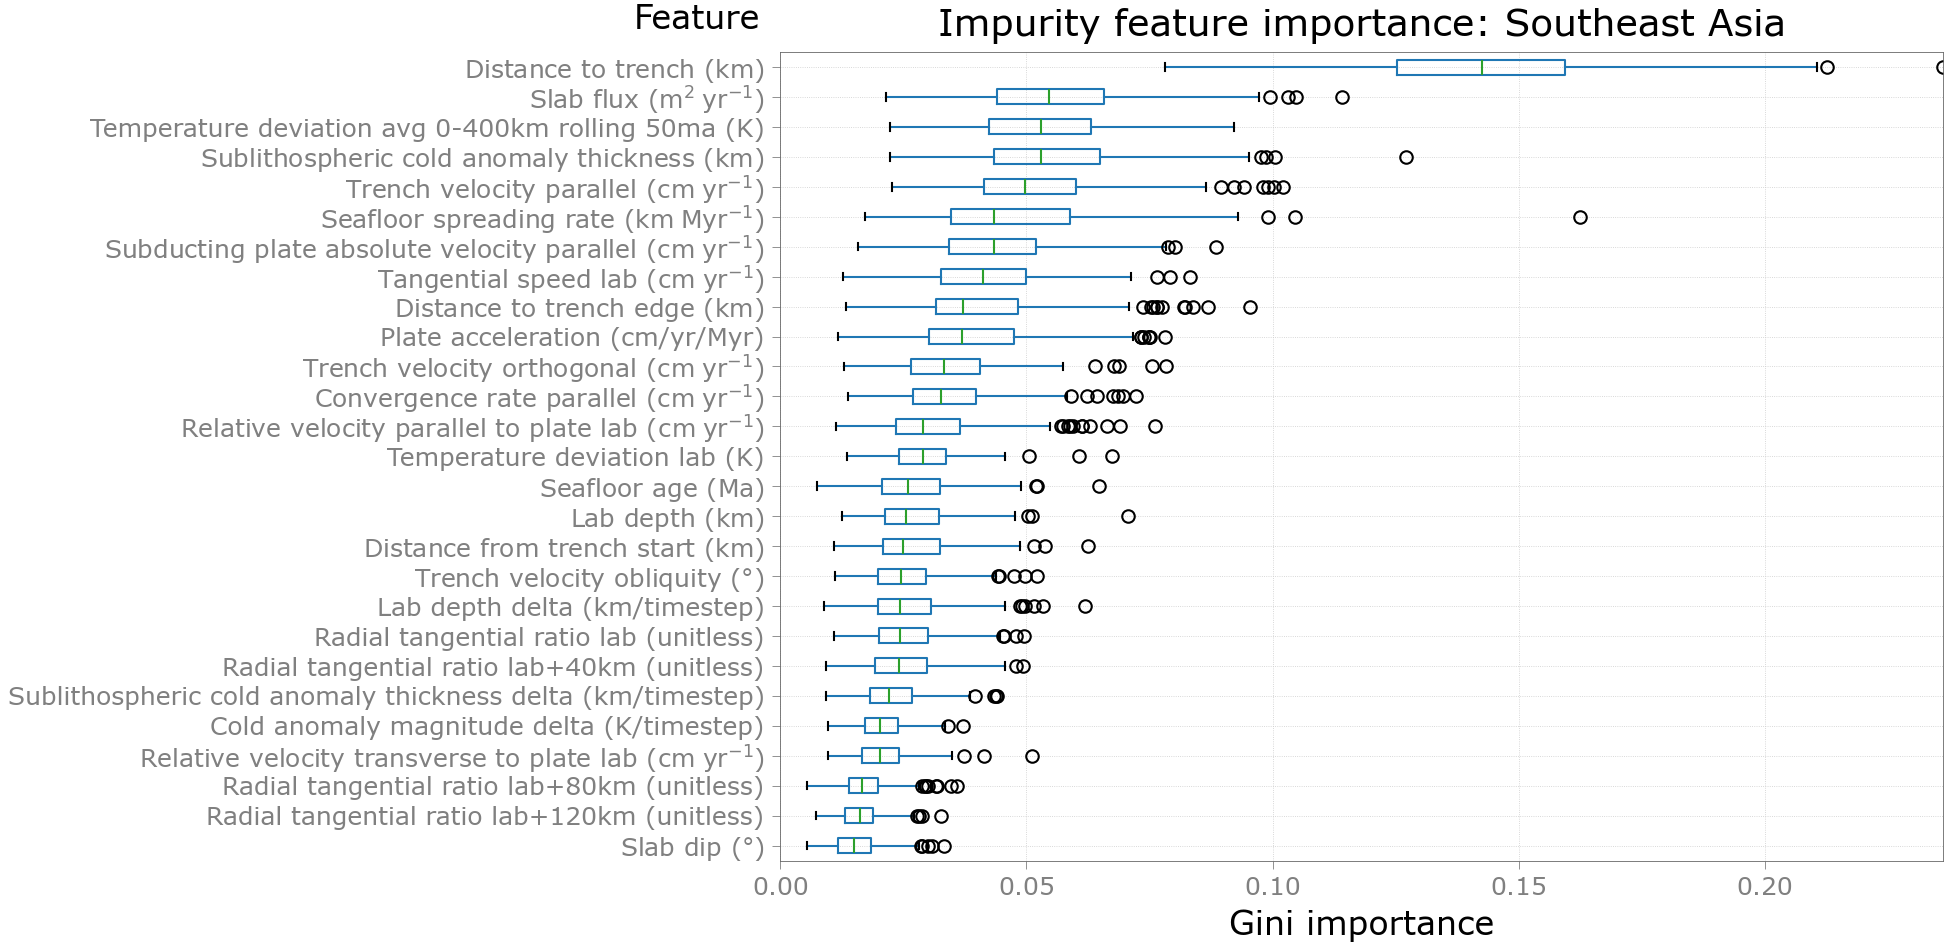

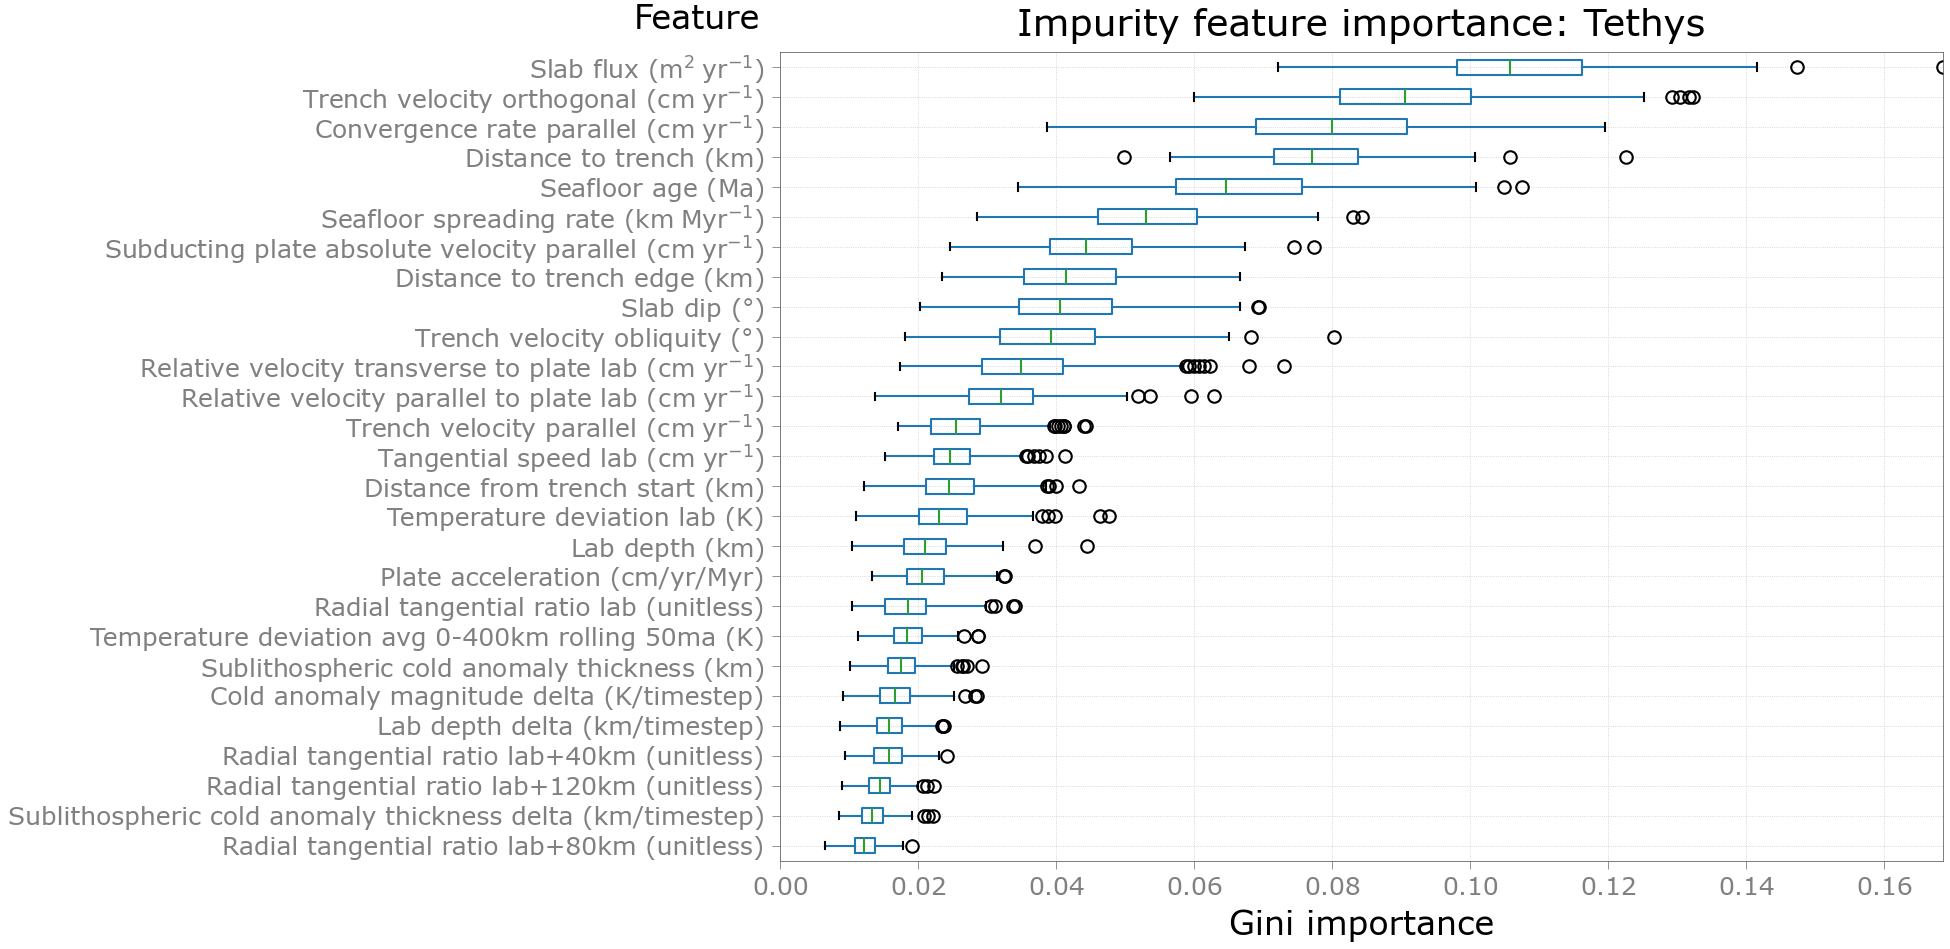

In [58]:
for region in data["region"].unique():
    r = "_".join(region.lower().split())
    subset = data[data["region"] == region]
    subset = subset[subset["label"].isin({"positive", "unlabelled"})]

    # Extract feature importance
    r = "_".join(region.lower().split())
    model = joblib.load(f"{pu_basename}_{r}.joblib")
    feature_names = model.feature_names_in_
    importances = []
    for train_idx, _ in cv.split(subset, subset["label"]):
        data_train = subset.iloc[train_idx, :]
        X_train = data_train[feature_names]
        y_train = data_train["label"].replace(replace).infer_objects()

        clf = clone(model)
        clf.fit(X_train, y_train)
        df_results = pd.DataFrame(
            np.vstack(
                [
                    i.feature_importances_
                    for i in clf["classifier"].estimators_
                ]
            ),
            columns=clf["preprocessing"].get_feature_names_out(),
        )
        importances.append(df_results)
    importances = pd.concat(importances, ignore_index=True)
    importances = importances[
        importances.median().sort_values(ascending=False).index
    ]
    importances.to_csv(f"{importance_basename}_{r}" + ".csv", index=False)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    importances.iloc[:, ::-1].boxplot(vert=False, ax=ax)
    ax.grid(linestyle="dotted")
    ax.set_xlim(0)
    ax.set_xlabel(
        "Gini importance",
        fontsize=label_size,
    )
    ax.set_ylabel(
        "Feature",
        rotation=0,
        ha="right",
        fontsize=label_size,
    )
    ax.yaxis.set_label_coords(x=-0.017, y=1.02)
    ax.set_title(
        f"Impurity feature importance: {region}",
        fontsize=title_size,
    )
    ax.set_yticks(
        ax.get_yticks(),
        [
            format_feature_name(i.get_text())
            for i in ax.get_yticklabels()
        ]
    )
    ax.tick_params(labelsize=tick_size)
    for ext in (".pdf", ".png"):
        fig.savefig(
            f"{importance_basename}_{r}" + ext,
            dpi=350,
            bbox_inches="tight",
        )